In [25]:
# ============================================
# 1. Library Imports and Dataset Loading
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (9, 5)

# Load dataset
df = pd.read_csv("../data/processed/all_countries_clean.csv")

print(f"✅ Dataset successfully loaded with shape: {df.shape}")
display(df.head())


✅ Dataset successfully loaded with shape: (42593, 23)


,Country,League,SeasonFile,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,...,HC,AC,HF,AF,HY,AY,HR,AR,TotalGoals,Over25
0,belgium,1,1920.csv,2019-07-26,Genk,Kortrijk,2,1,H,10.0,...,6.0,2.0,7.0,22.0,0.0,1.0,0.0,0.0,3,1
1,belgium,1,1920.csv,2019-07-27,Cercle Brugge,Standard,0,2,A,13.0,...,3.0,7.0,16.0,15.0,2.0,2.0,1.0,0.0,2,0
2,belgium,1,1920.csv,2019-07-27,St Truiden,Mouscron,0,1,A,10.0,...,5.0,5.0,10.0,21.0,2.0,4.0,0.0,0.0,1,0
3,belgium,1,1920.csv,2019-07-27,Waregem,Mechelen,0,2,A,7.0,...,4.0,2.0,14.0,21.0,3.0,1.0,0.0,0.0,2,0
4,belgium,1,1920.csv,2019-07-27,Waasland-Beveren,Club Brugge,1,3,A,7.0,...,1.0,14.0,18.0,12.0,3.0,1.0,0.0,0.0,4,1


In [12]:
# ============================================
# 2. General Overview
# ============================================

print("Dataset Information:")
df.info()

print("\nBasic Summary Statistics:")
display(df.describe(include='all').T.head(15))

print("\nMissing Values (Top 10):")
display(df.isnull().sum().sort_values(ascending=False).head(10))


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42593 entries, 0 to 42592
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     42593 non-null  object 
 1   League      42593 non-null  int64  
 2   SeasonFile  42593 non-null  object 
 3   Date        42593 non-null  object 
 4   HomeTeam    42593 non-null  object 
 5   AwayTeam    42593 non-null  object 
 6   FTHG        42593 non-null  int64  
 7   FTAG        42593 non-null  int64  
 8   FTR         42593 non-null  object 
 9   HS          42549 non-null  float64
 10  AS          42549 non-null  float64
 11  HST         42549 non-null  float64
 12  AST         42549 non-null  float64
 13  HC          42549 non-null  float64
 14  AC          42549 non-null  float64
 15  HF          42547 non-null  float64
 16  AF          42547 non-null  float64
 17  HY          42552 non-null  float64
 18  AY          42552 non-null  float64
 19  HR  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,42593,11,england,11952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
League,42593.0,NaN,NaN,NaN,1.419224,0.77984,0.0,1.0,1.0,2.0,3.0
SeasonFile,42593,6,2122.csv,7316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,42593,1587,2022-09-17,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomeTeam,42593,478,Sheffield Weds,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AwayTeam,42593,478,Blackburn,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FTHG,42593.0,NaN,NaN,NaN,1.468504,1.256949,0.0,1.0,1.0,2.0,9.0
FTAG,42593.0,NaN,NaN,NaN,1.198295,1.139182,0.0,0.0,1.0,2.0,13.0
FTR,42593,3,H,18310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HS,42549.0,NaN,NaN,NaN,12.92115,5.178769,0.0,9.0,12.0,16.0,46.0



Missing Values (Top 10):


AF     46
HF     46
AST    44
HS     44
AS     44
AC     44
HC     44
HST    44
HR     41
HY     41
dtype: int64

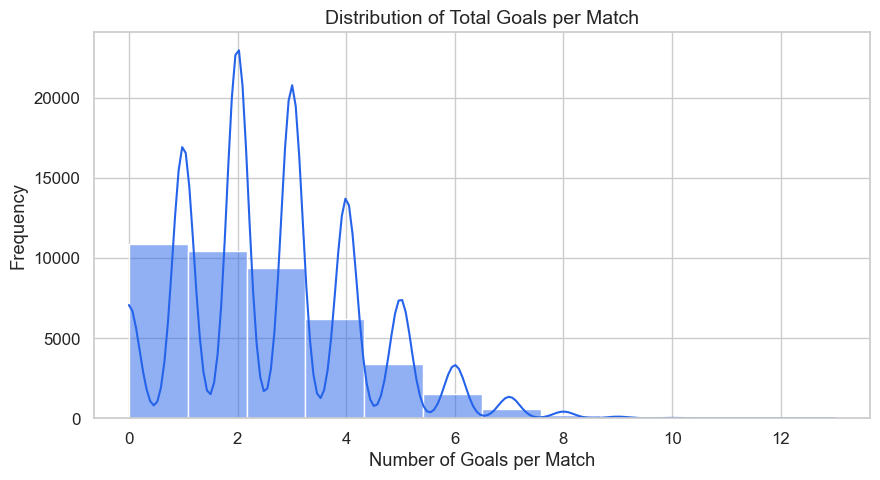

In [23]:
# ============================================
# 3. Goal Distribution Analysis
# ============================================

plt.figure(figsize=(9,5))
ax = sns.histplot(df["TotalGoals"], bins=12, kde=True, color="#2563EB", edgecolor="white")
plt.title("Distribution of Total Goals per Match", fontsize=14)
plt.xlabel("Number of Goals per Match")
plt.ylabel("Frequency")



plt.tight_layout()
plt.show()


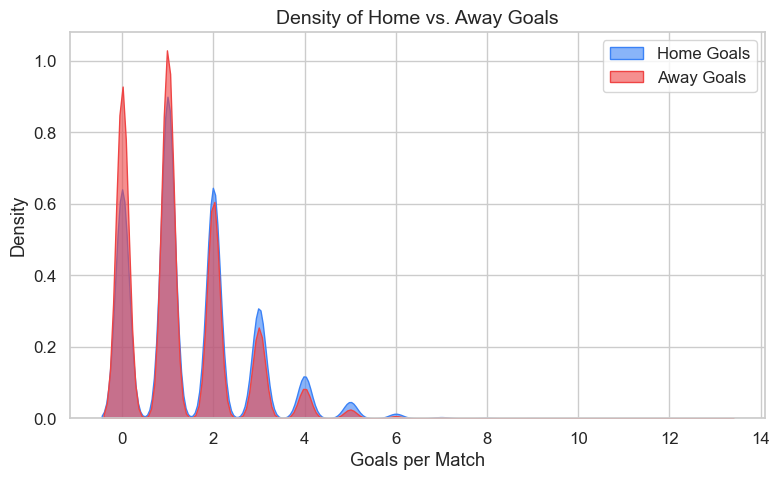

In [14]:
# ============================================
# 4. Home vs. Away Goals Comparison
# ============================================

plt.figure(figsize=(8,5))
sns.kdeplot(df["FTHG"], fill=True, color="#3B82F6", label="Home Goals", alpha=0.6)
sns.kdeplot(df["FTAG"], fill=True, color="#EF4444", label="Away Goals", alpha=0.6)
plt.title("Density of Home vs. Away Goals", fontsize=14)
plt.xlabel("Goals per Match")
plt.legend()
plt.tight_layout()
plt.show()


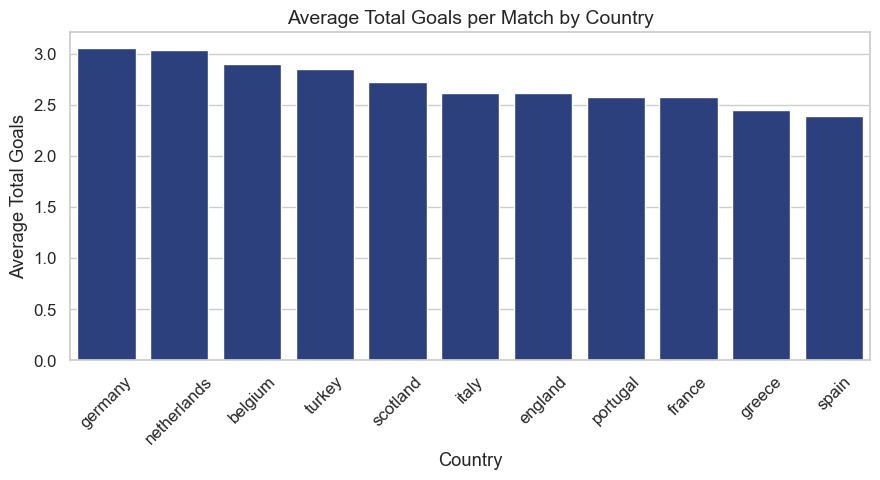

In [15]:
# ============================================
# 5. Country-Level Goal Statistics
# ============================================

avg_goals = df.groupby("Country")["TotalGoals"].mean().sort_values(ascending=False).reset_index()
sns.barplot(x="Country", y="TotalGoals", data=avg_goals, color="#1E3A8A")
plt.title("Average Total Goals per Match by Country", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Average Total Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


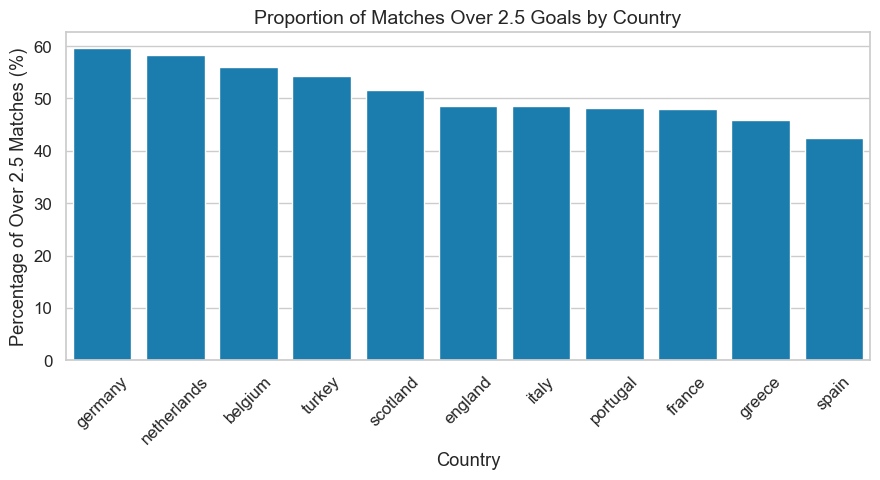

In [16]:
# ============================================
# 6. Share of Over 2.5 Goals by Country
# ============================================

country_over25 = df.groupby("Country")["Over25"].mean().sort_values(ascending=False).reset_index()
country_over25["Over25"] *= 100

sns.barplot(x="Country", y="Over25", data=country_over25, color="#0284C7")
plt.title("Proportion of Matches Over 2.5 Goals by Country", fontsize=14)
plt.ylabel("Percentage of Over 2.5 Matches (%)")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


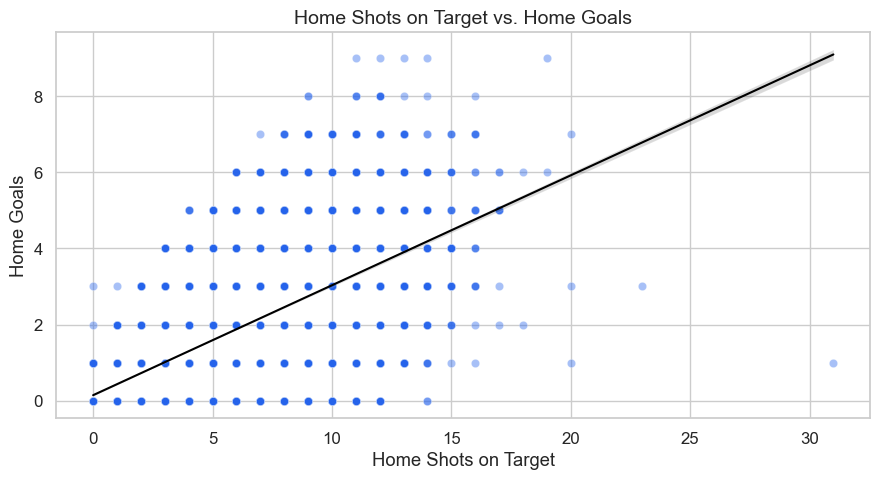

In [ ]:
# ============================================
# 7. Relationship Between Shots and Goals
# ============================================

sns.scatterplot(data=df, x="HST", y="FTHG", alpha=0.4, color="#2563EB")
sns.regplot(data=df, x="HST", y="FTHG", scatter=False, color="black", line_kws={"lw":1.5})
plt.title("Home Shots on Target vs. Home Goals", fontsize=14)
plt.xlabel("Home Shots on Target")
plt.ylabel("Home Goals")
plt.tight_layout()
plt.show()


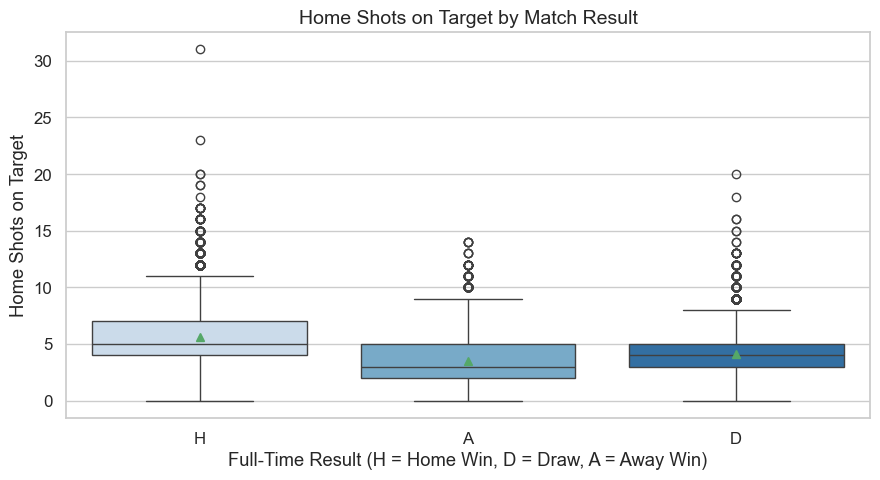

In [18]:
# ============================================
# 8. Offensive Activity by Match Outcome
# ============================================

sns.boxplot(data=df, x="FTR", y="HST", palette="Blues", showmeans=True)
plt.title("Home Shots on Target by Match Result", fontsize=14)
plt.xlabel("Full-Time Result (H = Home Win, D = Draw, A = Away Win)")
plt.ylabel("Home Shots on Target")
plt.tight_layout()
plt.show()


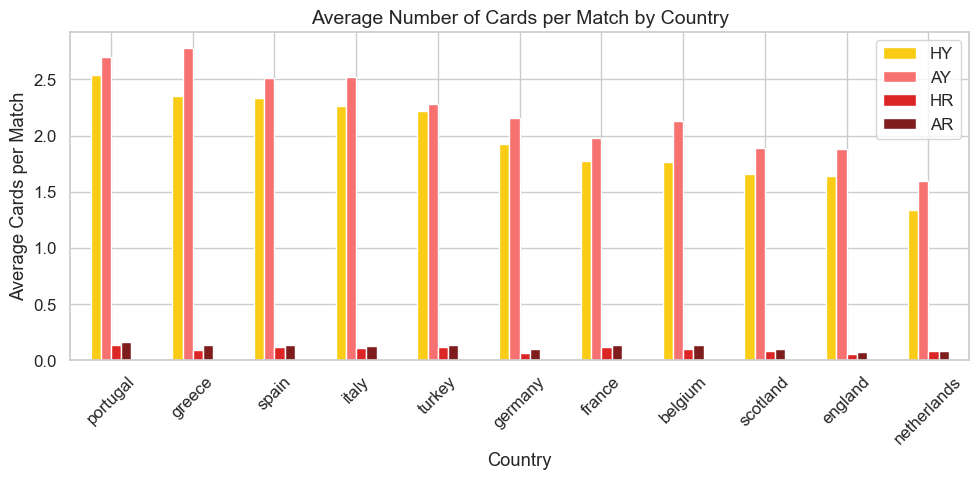

In [19]:
# ============================================
# 9. Fair Play and Discipline Metrics
# ============================================

discipline = df.groupby("Country")[["HY", "AY", "HR", "AR"]].mean().sort_values("HY", ascending=False)
discipline.plot(kind="bar", figsize=(10,5), color=["#FACC15","#F87171","#DC2626","#7F1D1D"])
plt.title("Average Number of Cards per Match by Country", fontsize=14)
plt.ylabel("Average Cards per Match")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


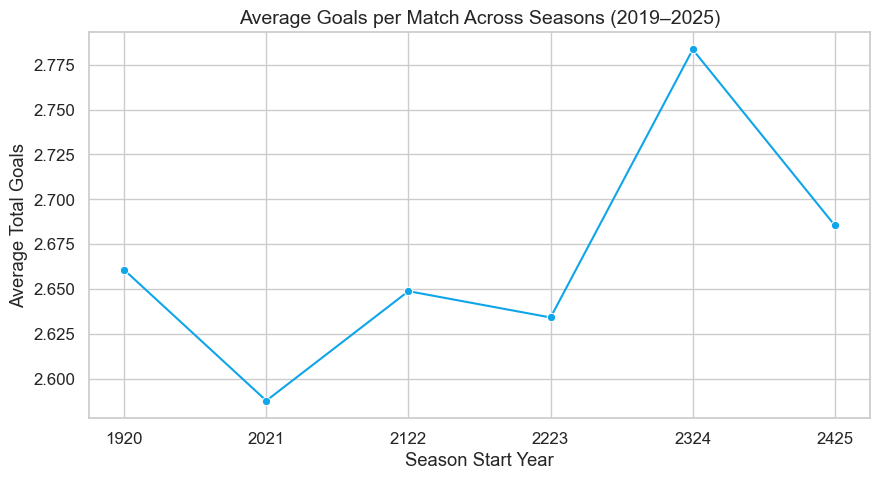

In [20]:
# ============================================
# 10. Seasonality and Long-Term Trends
# ============================================

df["Season"] = df["SeasonFile"].str.extract(r"(\d{4})")[0]
season_trend = df.groupby("Season")["TotalGoals"].mean().reset_index()

sns.lineplot(data=season_trend, x="Season", y="TotalGoals", marker="o", color="#0EA5E9")
plt.title("Average Goals per Match Across Seasons (2019–2025)", fontsize=14)
plt.ylabel("Average Total Goals")
plt.xlabel("Season Start Year")
plt.grid(True)
plt.tight_layout()
plt.show()


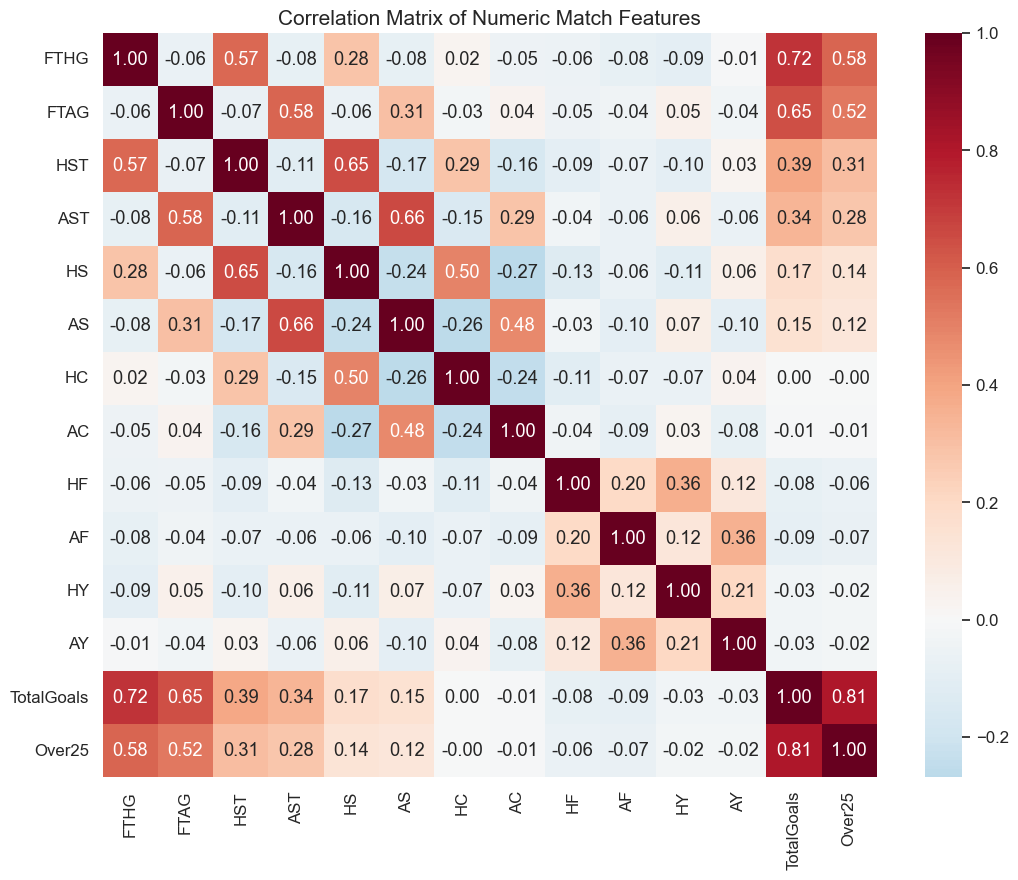

In [21]:
# ============================================
# 11. Correlation Matrix of Match Statistics
# ============================================

corr = df[["FTHG", "FTAG", "HST", "AST", "HS", "AS", "HC", "AC", "HF", "AF", "HY", "AY", "TotalGoals", "Over25"]].corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numeric Match Features", fontsize=15)
plt.tight_layout()
plt.show()


In [ ]:
## Dataset Overview

The dataset contains **42,593 football matches** across **11 European countries** and **multiple leagues (1st to 3rd divisions)** covering the seasons from **2019–20 to 2024–25**.  
It combines match results, basic statistics (shots, corners, cards), and metadata (country, league, season, teams).

| Property | Description |
|-----------|--------------|
| **Rows** | 42,593 matches |
| **Columns** | 23 features |
| **Countries** | 11 (England, Spain, Italy, Germany, France, etc.) |
| **Leagues** | 4 (top divisions from each country) |
| **Date Range** | 2019-07-26 → 2025-06-01 |
| **Data Quality** | Very high – less than 0.2% missing values (mostly in advanced stats) |

### Missing Values Summary
Most missing data are found in match statistics such as fouls and shots, but the overall volume is negligible:

| Column | Missing Count |
|---------|----------------|
| AF | 46 |
| HF | 46 |
| AST | 44 |
| HS | 44 |
| AS | 44 |
| AC | 44 |
| HC | 44 |
| HST | 44 |
| HR | 41 |
| HY | 41 |

This confirms the dataset’s **completeness and reliability** for modeling.

---

## Statistical Highlights

| Metric | Value |
|---------|--------|
| **Total Matches** | 42,593 |
| **Countries** | 11 |
| **Average Total Goals per Match** | 2.67 |
| **Average Home Goals** | 1.47 |
| **Average Away Goals** | 1.20 |
| **Over 2.5 Goals Rate** | 49.9% |

---

## Observed Patterns and Insights

### Goal Scoring Patterns
- The **distribution of total goals** is **right-skewed**, peaking between **2 and 3 goals per match**.  
- Extreme goal counts (>7 goals) are very rare, confirming the stability of European match scoring patterns.  
- The **Over/Under 2.5 line** is evenly balanced — around **half of all matches exceed 2.5 goals**.

### Home Advantage
- Home teams score on average **1.47 goals**, compared to **1.20 for away teams**, clearly confirming the **home advantage effect**.  
- The density plots show a consistent right shift for home goals — home teams perform better offensively across all leagues.

### Cross-Country Comparison
- **Germany** and **Netherlands** are the highest-scoring leagues (≈3.0+ goals per match),  
  while **Greece** and **Spain** show more defensive play (~2.4 goals per match).  
- The share of Over 2.5 matches mirrors these trends:  
  **Germany (60%)**, **Netherlands (58%)**, and **Belgium (55%)** dominate high-scoring games.

### Offensive Efficiency (Shots vs Goals)
- A clear **positive linear relationship** exists between **shots on target** and **goals scored**.  
- The regression analysis shows that each additional shot on target significantly raises the expected number of goals.  
- Boxplots confirm that **winning teams** consistently produce more shots on target, underlining offensive precision as a key success factor.

### Discipline and Fair Play
- On average, teams receive around **2 yellow cards per match**.  
- **Portugal, Greece, and Spain** show the most aggressive styles (higher yellow and red card counts).  
- **Netherlands and England** are the cleanest leagues in disciplinary terms.  
- While cards have weak correlation with goals, they may indirectly influence **tempo and attacking flow**.

### Seasonal Stability
- Across seasons (2019–2025), the **average goals per match remain stable** between **2.6 and 2.8**.  
- No long-term increasing or decreasing trend was detected, suggesting a **stationary process** — ideal for predictive modeling.

### Correlation Analysis
- **FTHG ↔ HST (r = 0.57)** and **FTAG ↔ AST (r = 0.58)** show strong correlations,  
  confirming that **shots on target** are highly predictive of goal outcomes.  
- **TotalGoals ↔ Over25 (r = 0.81)** — expected since Over25 is derived from total goals.  
- Other match stats like fouls or cards exhibit near-zero correlation with goal-based targets, implying **limited predictive power**.

## Final Conclusion

The EDA reveals clear and logical football dynamics consistent with real-world knowledge:
- Strong home advantage and offensive–defensive contrasts across leagues.  
- Stable scoring behavior over multiple seasons.  
- Offensive metrics as the most reliable predictors of total goals and Over/Under outcomes.  

This foundational understanding will directly support:
- the design of robust machine learning models, and  
- the quantification of **accuracy-driven profit improvement** in the upcoming analytical phases.

---

**Next Notebook:** `02_baseline_model.ipynb`  
Proceed to the baseline predictive model (`02_baseline_model.ipynb`)  
using the 8 mandatory features:  
`Div, Date, Time, HomeTeam, AwayTeam, FTHG, FTAG, FTR`.  
This will establish the initial prediction accuracy \(A_0\),  
which will later be compared with the extended feature model \(A_1\).

In [26]:
import os
file_path = r"C:\Users\pavj1\ml2-semestral-project\data\processed\all_countries_clean.csv"
print(f"File size: {os.path.getsize(file_path) / (1024*1024):.2f} MB")


File size: 4.49 MB
